## ML - Heart Disease Prediction Using Logistic Regression

#### 1: Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

#### 2. Data Preparation

In [2]:
disease_df = pd.read_csv(r'C:\users\hp\downloads\framingham.csv')

In [3]:
disease_df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


###### Loading and Handling Missing Values from the Dataset

In [4]:
disease_df.drop(['education'],axis=1, inplace=True)
disease_df.rename(columns = {'male':'Sex_male'}, inplace=True)

In [5]:
disease_df.head()

,Sex_male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [7]:
disease_df.isnull().sum()

Sex_male             0
age                  0
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [9]:
disease_df.dropna(axis=0, inplace=True)

In [10]:
disease_df.isnull().sum()

Sex_male           0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [11]:
print(disease_df.TenYearCHD.value_counts())

TenYearCHD
0    3179
1     572
Name: count, dtype: int64


#### 3: Splitting the Dataset into Test and Train Sets

In [12]:
X = np.asarray(disease_df[['age', 'Sex_male', 'cigsPerDay', 
                           'totChol', 'sysBP', 'glucose']])
y = np.asarray(disease_df['TenYearCHD'])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (2625, 6) (2625,)
Test set: (1126, 6) (1126,)


#### 4: Exploratory Data Analysis of Heart Disease Dataset

###### Ten Year's CHD Record of all the patients available in the dataset:

C:\Users\HP\AppData\Local\Temp\ipykernel_2472\2933583651.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TenYearCHD', data=disease_df, palette="BuGn_r")


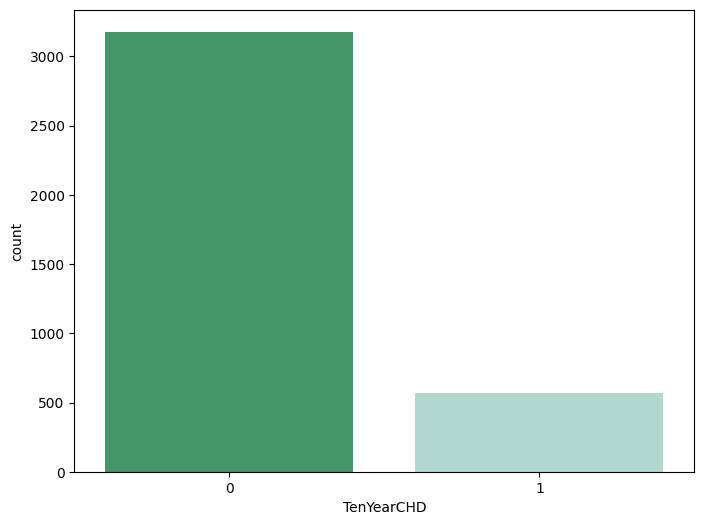

In [20]:
plt.figure(figsize=(8,6))
sns.countplot(x='TenYearCHD', data=disease_df, palette="BuGn_r")
plt.show()

###### Counting number of patients affected by CHD where (0= Not Affected; 1= Affected)

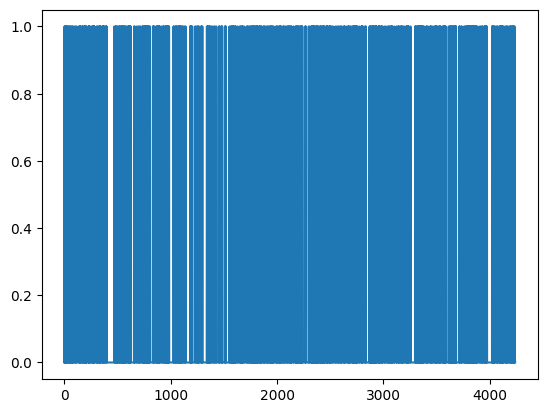

In [16]:
laste = disease_df['TenYearCHD'].plot()
plt.show(laste)

#### 5: Fitting Logistic Regression Model for Heart Disease Prediction

In [17]:
from sklearn.linear_model import LogisticRegression 
reg = LogisticRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

#### 6: Evaluating Logistic Regression Model

In [18]:
from sklearn.metrics import accuracy_score
Accuracy = accuracy_score(y_test,y_pred)
print('Accuracy of the Logistic Model: ', Accuracy)

Accuracy of the Logistic Model:  0.8339253996447602


###### Plotting Confusion Matrix

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       938
           1       0.52      0.06      0.11       188

    accuracy                           0.83      1126
   macro avg       0.68      0.52      0.51      1126
weighted avg       0.79      0.83      0.77      1126



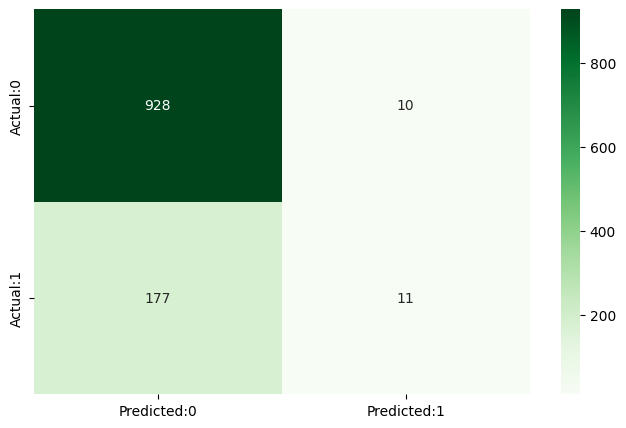

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
conf_matrix = pd.DataFrame(data = cm, 
                           columns = ['Predicted:0', 'Predicted:1'], 
                           index =['Actual:0', 'Actual:1'])

plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Greens")

plt.show()